In [251]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import yfinance as yf


## 1) Model du CAPM:  

$$E(R_i) = R_f + \beta_{i}(E(R_m)-R_f)$$
$$\beta_{i} = \dfrac{Cov(R_i;R_m)}{Var(R_m)}$$

Où:  
$R_f$: taux sans risque (ex: obligation d'état, bon du trésor)  
$R_m$: représente le rendement de l'ensemble du marché (ou d'un indice de marché représentatif)  
$\beta$: rémuneration structuelle  




$R^2$:Coefficient de détermination  
Le $R²$ mesure la proportion de la variance expliquée par le modèle.
$$
R^2 = \frac{SCR}{SCT} = 1 - \frac{SCE}{SCT}
$$

Où :
- $\text{SCR} = \sum (\hat{Y}_i - \bar{Y})^2$ (somme des carrés expliquée)
- $\text{SCE} = \sum (Y_i - \hat{Y}_i)^2$ (somme des carrés des erreurs)
- $\text{SCT} = \sum (Y_i - \bar{Y})^2$ (somme des carrés totale)


calcule de $E(R_m)$ avec la Prime de risque historique + taux sans risque  

$E(R_m) = R_f + prime\ de\ risque\ historique $  

avec :  
$prime\ de\ risque\ historique\ (ERP) = \dfrac{1}{T} \Sigma (R_{m,t} - R_{f,t}) $  

Comme on va faire un pf a valeur usa je pense que je vais prendre une obligation du tresort a 10 ans américaine pour ça.  
$R_f$ = US 10 Year Treasury Note Yield


In [252]:
# calcule du beta ainsi que des parametres : 
def Cov(X, Y):
    return np.sum((X - np.mean(X)) * (Y - np.mean(Y))) / (len(X) - 1)
def Var(Y):
    return np.sum((Y - np.mean(Y)) ** 2) / (len(Y) - 1)
def Beta(X, Y):
    return Cov(X, Y) / Var(Y)


In [253]:
tickers = ["AAPL", "MSFT", "JPM", "XOM", "NVDA", "ASML", "MC.PA", "SIE.DE", "NESN.SW", "GLD"]
benchmark = "URTH"
all_tickers = tickers + [benchmark]
df = yf.download(all_tickers, start="2022-01-01")["Close"].pct_change().dropna()
df = df.iloc[:-1]

C:\Users\Tom\AppData\Local\Temp\ipykernel_1120\456570850.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start="2022-01-01")["Close"].pct_change().dropna()
[*********************100%***********************]  11 of 11 completed
C:\Users\Tom\AppData\Local\Temp\ipykernel_1120\456570850.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df = yf.download(all_tickers, start="2022-01-01")["Close"].pct_change().dropna()


In [254]:
betas = []
for tickers in df: 
    b = Beta(df[tickers],df["URTH"])
    betas.append(b)

betas = pd.Series(betas, index= all_tickers)
betas.head(10)

AAPL       1.238032
MSFT       1.862281
JPM        0.192830
XOM        0.952716
NVDA       0.668906
ASML       1.147379
MC.PA      0.112114
SIE.DE     2.202158
NESN.SW    0.760307
GLD        1.000000
dtype: float64

In [255]:

sp500 = yf.download("^GSPC", start = "2000-01-01")['Close']
us10Y = yf.download("^TNX", start="2000-01-01")['Close']

## passage des données en annuel car yfinance ne le fait pas... 
sp500_yearly = sp500.resample('YE').last()
us10_yearly = us10Y.resample('YE').mean()

sp500_returns = sp500_yearly.pct_change().dropna() * 100 

sp500_returns.head()

data = pd.concat([sp500_returns,us10_yearly], axis=1).dropna()
R_f = data['^TNX'].iloc[-1]
data = data.iloc[:-1]

ERP = (np.mean(data["^GSPC"] - data["^TNX"]))

print(f'la prime de risque historique est de {round(ERP,2)} % ')

E_Rm = round(R_f + ERP,2) 
print(f'L\'esperence du marché est de {E_Rm} % ')

### on le passe en rdm journalier pour les calcules de la variance et du voile 
R_f_daily = R_f / 252
E_Rm_daily = E_Rm / 252

print(f'L\'esperence du marché est de {E_Rm_daily} % ')
E_Ri_daily = R_f_daily + betas * (E_Rm_daily - R_f_daily)
E_Ri_daily = pd.Series(E_Ri_daily, index= all_tickers)
E_Ri_daily = E_Ri_daily.iloc[:-1]

C:\Users\Tom\AppData\Local\Temp\ipykernel_1120\76207110.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start = "2000-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Tom\AppData\Local\Temp\ipykernel_1120\76207110.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  us10Y = yf.download("^TNX", start="2000-01-01")['Close']
[*********************100%***********************]  1 of 1 completed

la prime de risque historique est de 5.19 % 
L'esperence du marché est de 9.37 % 
L'esperence du marché est de 0.03718253968253968 % 


In [256]:
variance = []
for tickers in df:
    v = Var(df[tickers])
    variance.append(v)
variance = pd.Series(variance, index=all_tickers)
variance = variance.iloc[:-1] # on sort le 'URTH'

std_dev = variance**(1/2)
std_dev


AAPL       0.017584
MSFT       0.026540
JPM        0.011355
XOM        0.015486
NVDA       0.019028
ASML       0.016868
MC.PA      0.011143
SIE.DE     0.032924
NESN.SW    0.018847
GLD        0.010415
dtype: float64

In [257]:
sharp_ratio = (E_Ri_daily - R_f_daily) / std_dev
sharp_ratio

AAPL       1.449795
MSFT       1.444923
JPM        0.349699
XOM        1.266828
NVDA       0.723895
ASML       1.400663
MC.PA      0.207185
SIE.DE     1.377289
NESN.SW    0.830690
GLD        1.977217
dtype: float64

In [258]:
pf = pd.DataFrame({
    "sharp ratio" : sharp_ratio,
    "ecart type": std_dev,
    "variance": variance, 
    "esperence": (E_Ri_daily)*252,
    "Beta": betas
}, index = all_tickers)

pf = pf.iloc[:-1]
pf

,sharp ratio,ecart type,variance,esperence,Beta
AAPL,1.449795,0.017584,0.000309,10.605179,1.238032
MSFT,1.444923,0.026540,0.000704,13.844500,1.862281
JPM,0.349699,0.011355,0.000129,5.181483,0.192830
XOM,1.266828,0.015486,0.000240,9.124637,0.952716
NVDA,0.723895,0.019028,0.000362,7.651907,0.668906
ASML,1.400663,0.016868,0.000285,10.134772,1.147379
MC.PA,0.207185,0.011143,0.000124,4.762632,0.112114
SIE.DE,1.377289,0.032924,0.001084,15.608169,2.202158
NESN.SW,0.830690,0.018847,0.000355,8.126200,0.760307
GLD,1.977217,0.010415,0.000108,9.370000,1.000000


In [259]:
cov_matrice = df.drop(columns=["URTH"]).cov()
cov_matrice

Ticker,AAPL,ASML,GLD,JPM,MC.PA,MSFT,NESN.SW,NVDA,SIE.DE,XOM
Ticker,,,,,,,,,,
AAPL,0.000309,0.000246,0.000009,0.000107,0.000083,1.759067e-04,1.277083e-05,0.000296,0.000081,0.000060
ASML,0.000246,0.000704,0.000040,0.000151,0.000175,2.364837e-04,1.258103e-05,0.000592,0.000205,0.000066
GLD,0.000009,0.000040,0.000129,0.000006,0.000006,1.084086e-05,4.903506e-06,0.000022,0.000012,0.000031
JPM,0.000107,0.000151,0.000006,0.000240,0.000070,9.080095e-05,8.620079e-06,0.000180,0.000092,0.000074
MC.PA,0.000083,0.000175,0.000006,0.000070,0.000362,6.744539e-05,5.367543e-05,0.000122,0.000182,0.000023
MSFT,0.000176,0.000236,0.000011,0.000091,0.000067,2.845357e-04,-2.339247e-07,0.000342,0.000072,0.000019
NESN.SW,0.000013,0.000013,0.000005,0.000009,0.000054,-2.339247e-07,1.241620e-04,-0.000024,0.000034,-0.000004
NVDA,0.000296,0.000592,0.000022,0.000180,0.000122,3.424378e-04,-2.445371e-05,0.001084,0.000173,0.000043
SIE.DE,0.000081,0.000205,0.000012,0.000092,0.000182,7.182012e-05,3.436570e-05,0.000173,0.000355,0.000024


Markowitz & Modern pf theory  
$$\sigma^2_p = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \sigma_{ij} = w^T \cdot \Sigma \cdot w$$

Où :

\begin{aligned}
&\sigma^2_p && \text{: variance du portefeuille} \\
&w_i, w_j && \text{: poids des actifs } i \text{ et } j \text{ dans le portefeuille} \\
&\sigma_{ij} && \text{: covariance entre l'actif } i \text{ et l'actif } j \\
&\sigma_{ii} && \text{: variance de l'actif } i \text{ (quand } i = j \text{)} \\
&w^T && \text{: vecteur de poids transposé} \\
&\Sigma && \text{: matrice de covariances } (n \times n)
\end{aligned}

In [260]:
## creation de poids aleatoir pour le voile 
w_pf = []
for w in range(100000): 
    w = np.random.random(10)
    w = w / w.sum()
    w_pf.append(w)

# exemple avec contrainte de poids max à 30%
# w = np.random.dirichlet(np.ones(10))
# w = np.clip(w, 0, 0.30)
# w = w / w.sum()

w_pf = np.array(w_pf)

rendement_pf = w_pf @ E_Ri_daily.values
variance_pf = np.array([w @ cov_matrice @ w for w in w_pf])  
volatilite_pf = np.sqrt(variance_pf)
sharpe_pf = (rendement_pf - R_f_daily) / volatilite_pf


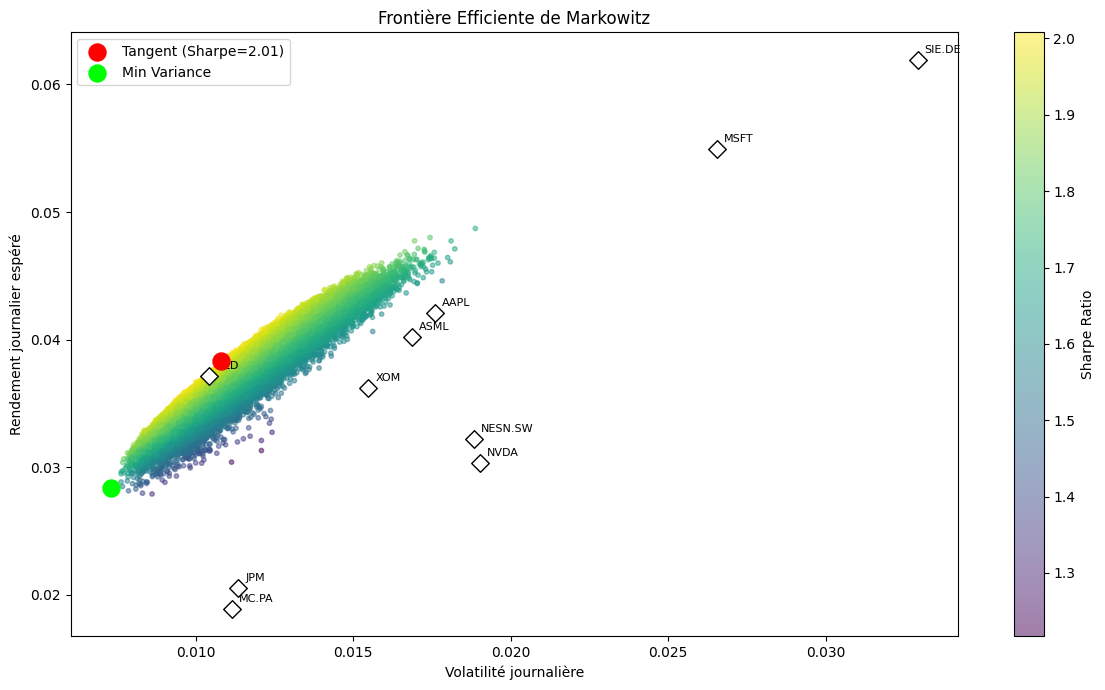

In [261]:
fig, ax = plt.subplots(figsize=(12, 7))

# nuage de points des portefeuilles coloré par sharpe
scatter = ax.scatter(volatilite_pf, rendement_pf, c=sharpe_pf, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# portefeuille tangent (sharpe max)
idx_tangent = np.argmax(sharpe_pf)
ax.scatter(volatilite_pf[idx_tangent], rendement_pf[idx_tangent], 
    color='red', s=150, zorder=5, label=f'Tangent (Sharpe={sharpe_pf[idx_tangent]:.2f})')

# portefeuille minimum variance
idx_min_var = np.argmin(variance_pf)
ax.scatter(volatilite_pf[idx_min_var], rendement_pf[idx_min_var], 
    color='lime', s=150, zorder=5, label=f'Min Variance')

# actifs individuels
tickers_only = ["AAPL", "MSFT", "JPM", "XOM", "NVDA", "ASML", "MC.PA", "SIE.DE", "NESN.SW", "GLD"]
for ticker in tickers_only:
    vol_i = std_dev[ticker]
    ret_i = E_Ri_daily[ticker]
    ax.scatter(vol_i, ret_i, s=80, zorder=5, marker='D', color='white', edgecolors='black')
    ax.annotate(ticker, (vol_i, ret_i), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('Volatilité journalière')
ax.set_ylabel('Rendement journalier espéré')
ax.set_title('Frontière Efficiente de Markowitz')
ax.legend()
plt.tight_layout()
plt.show()

In [262]:
idx_tangent = np.argmax(sharpe_pf)

pf_tangent = pd.DataFrame({
    "Ticker": tickers_only,
    "Poids (%)": (w_pf[idx_tangent] * 100).round(2)
}).set_index("Ticker")

print(f"Sharpe : {sharpe_pf[idx_tangent]:.4f}")
print(f"Rendement journalier : {rendement_pf[idx_tangent]:.6f}")
print(f"Volatilité journalière : {volatilite_pf[idx_tangent]:.6f}")
print(f"Rendement annualisé : {rendement_pf[idx_tangent]*252:.2f} %")
print(f"Volatilité annualisée : {volatilite_pf[idx_tangent]*np.sqrt(252)*100:.2f} %")
print()
print(pf_tangent)

Sharpe : 2.0081
Rendement journalier : 0.038303
Volatilité journalière : 0.010813
Rendement annualisé : 9.65 %
Volatilité annualisée : 17.16 %

         Poids (%)
Ticker            
AAPL         11.93
MSFT          1.19
JPM           7.18
XOM          14.86
NVDA          5.31
ASML         19.71
MC.PA         0.23
SIE.DE        7.18
NESN.SW       6.23
GLD          26.19
